In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 1
dim = 2
nx = 16
dx = L/nx

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros_like(domain.min)
domain.max = torch.ones_like(domain.max) * L

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.0, 0, shiftScheme = 'delta') 
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

particles = particles._replace(positions = particles.positions - dx/2)
particlesLR = particlesLR._replace(positions = particlesLR.positions - dx/4)    

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

particleState = wcstateToState(particles)


0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import numpy as np
import jax
import exponax as ex
import matplotlib.pyplot as plt
import h5py

NUM_POINTS = nx

datafile = h5py.File(f"data_diffusedNoise_nx_{nx}.h5", "r")

u0 = np.array(datafile['u_0'])
jacobian = np.array(datafile['d'])
hessian = np.array(datafile['d2'])
patrician = np.array(datafile['d3'])

selected_seed = 0

values = [u0[selected_seed], jacobian[selected_seed], hessian[selected_seed], patrician[selected_seed]]
values = [torch.tensor(v, device=device, dtype=dtype).flatten(-2).T for v in values]

for v in values:
    print(v.shape)

torch.Size([256, 1])
torch.Size([256, 2])
torch.Size([256, 2, 2])
torch.Size([256, 2, 2, 2])


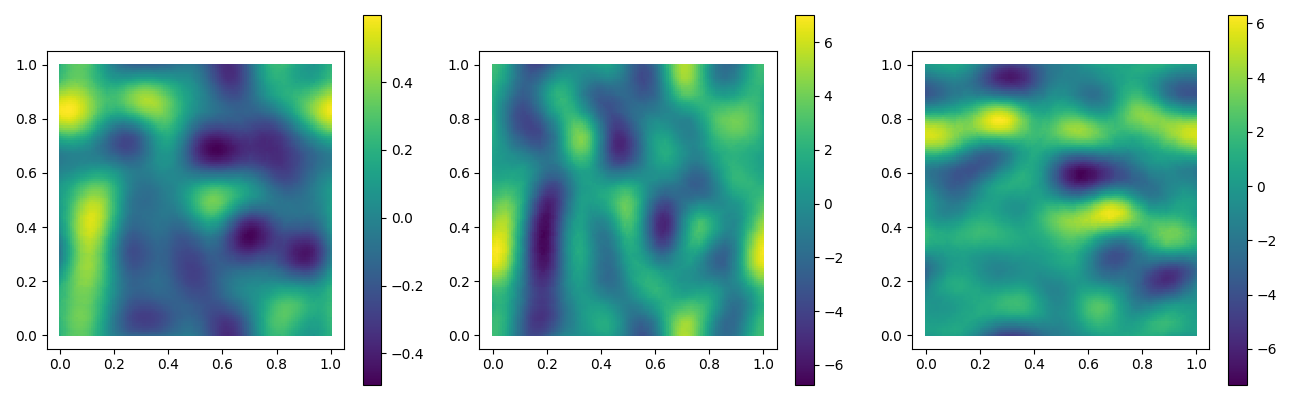

In [4]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = values[0],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,  
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = values[1],
  which = 'fluid',
  mapping = '.y',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=True, markerSize=4,
  streamLines = False)


fig.tight_layout()


In [5]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

Number of neighbors: torch.Size([256]) tensor([45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
        45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45, 45,
 

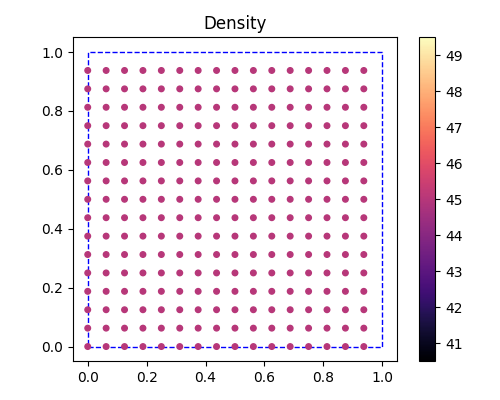

In [6]:

mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]

neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)


numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries

print('Number of neighbors:', numNeighbors.shape, numNeighbors)

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [7]:
inputFeatures = values[0]

gt = values[0]**2

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

Input features: torch.Size([256, 1]), GT: torch.Size([256, 1])
Input features statistics: max: 0.9999999403953552, min: -0.9529105424880981, mean: 1.862645149230957e-09, std: 0.3851446509361267
GT statistics: max: 0.9999998807907104, min: 4.389895877920935e-07, mean: 0.14775696396827698, std: 0.1911180466413498


In [8]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 5
multiHeads = 4
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = particleState.positions.shape[-1]

In [9]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())

torch.Size([11520])
Maximum distance:  0.9013878107070923


In [10]:
from models.common import CommonConfiguration
import copy

baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=2,
    mlp_latent_dim = 32,
    mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)

In [11]:
from layers.layer_tokenEncoder import TokenEncoderConfig
encodeConfig = TokenEncoderConfig()

display(encodeConfig)
encodeConfig.projection_linear=True

decodeConfig = copy.deepcopy(encodeConfig)
decodeConfig.projection_linear=True

TokenEncoderConfig(token_input_dim=0, token_output_dim=None, token_latent_dim=None, skip_connection=True, projection=True, projection_linear=True, projection_mlp_dict=None, position_bias=None, position_bias_mixing=None, position_bias_linear=True, position_bias_mlp_dict=None, position_bias_dim=None, use_ffn=False, ffn_linear=False, ffn_mlp_dict=None, ffn_skip_connection=False, pre_norm=False, post_norm=False, final_activation=None)

In [12]:
from models.basicTransformer import BasicTransformer
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel
import torch.nn as nn
from models.basicEncoder import BasicEncoder


def printTensor(name, tensor):
    print(''.join(['-']*80))
    print(f'Tensor {name}: shape {tensor.shape}, dtype {tensor.dtype}, device {tensor.device}')
    print(f'\tmin: {tensor.min().item()}, max: {tensor.max().item()}, mean: {tensor.mean().item()}, std: {tensor.std().item()}')
    # print(tensor)
    for i in range(tensor.shape[-1]):
        if len(tensor.shape) == 2:
            print(f'\tChannel {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
        else:
            print(f'\tChannel {i}: min: {tensor[:,:,i].min().item()}, max: {tensor[:,:,i].max().item()}, mean: {tensor[:,:,i].mean().item()}, std: {tensor[:,:,i].std().item()}, data: ')

    # for i in range(tensor.shape[-2]):
    #     print(f'\tParticle {i}: min: {tensor[:,i].min().item()}, max: {tensor[:,i].max().item()}, mean: {tensor[:,i].mean().item()}, std: {tensor[:,i].std().item()}, data: ')
    print(''.join(['-']*80))

class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, transformerConfig, 
                 numTransformers, mode = 'transformer'):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=encoderConfig,
            verbose = False,
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = transformerConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,

                    # attention_softmax = False,

                    verbose = False,
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=baseConfigNoEncoders,

                    verbose = False,
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = baseConfigNoEncoders,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = True,
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            tokenEncoderConfig=decoderConfig,
            verbose = True,
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        # print('Input node_attr shape:', node_attr.shape)
        printTensor('node_attr', node_attr)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        # print('Encoded input shape:', x.shape)
        printTensor('encoded node_attr', x)
        for i, transformer in enumerate(self.transformers):
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            printTensor(f'after transformer {i}', x)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        # print('Output shape:', out.shape)
        printTensor('output', out)
        return out
    
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

multiHeads = 1
transformerFeatures = 11



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=1,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=3,
    mlp_latent_dim = 32,
    mlp_activation = 'sigmoid',
)

basicModel = basicTest(
    input_dim = inputFeatures.shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 1,
    encoderConfig = encodeConfig,
    decoderConfig = decodeConfig,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 1,
    mode = 'gnn'
).to(device)

Initializing GNN Model...
	Adding input edge encoder.
#                   EdgeEnc|Initializing BasisEncoder Layer                    #
EdgeEnc|BasisEncoder: basis_terms=[6, 6], basis_function=['ffourier', 'ffourier'], mode=cat, spatial_dim=2
EdgeEnc|	BasisEncoder: basisShape=[12], total basis terms=12
EdgeEnc|	BasisEncoder: project_out=11, outputShape=11
EdgeEnc|BasisEncoder: basisShape=[12], total basis terms=12, outputShape=11
EdgeEnc|BasisEncoder: project_out=True, outputShape=11
EdgeEnc|BasisEncoder: projector=Linear(in_features=12, out_features=11, bias=False)
EdgeEnc|BasisEncoder Layer Initialized
Initial token dimensions: 11
Initial edge dimensions: 0
Set up input dimensions: token_input_dim=11, edge_feature_dim=11
	Adding message passing layer 1/1.
#                       Initializing MessagePassingLayer                       #
	Latent dimension: 11
	Edge dimension: 11
	Transformer features: 11
	Number of heads: 1
#                           Encoding Value Tokens...            

In [13]:
from layers.layer_positionEncoder import BasisEncoder
bEnc = BasisEncoder(
    verbose = True,

    spatial_dim = 2,
    base_encoding = True,
    base_function = 'pfourier',
    base_terms = 11,
    base_mode = 'cat',

    projection = True,
    projection_linear = True,
    projection_dim = 7,
    projection_bias = False
).to(device)

neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
edge_attr = xij_ / h_i[:,None]

encodedEdges = bEnc(edge_attr).detach()

#                       Initializing BasisEncoder Layer                        #
BasisEncoder: basis_terms=[11, 11], basis_function=['pfourier', 'pfourier'], mode=cat, spatial_dim=2
	BasisEncoder: basisShape=[22], total basis terms=22
	BasisEncoder: project_out=7, outputShape=7
BasisEncoder: basisShape=[22], total basis terms=22, outputShape=7
BasisEncoder: project_out=True, outputShape=7
BasisEncoder: projector=Linear(in_features=22, out_features=7, bias=False)
BasisEncoder Layer Initialized
#                          BasisEncoder Forward Pass                           #
	Input Positions shape: torch.Size([11520, 2]), min: -0.75, max: 0.75, mean: 0.0, std: 0.4714147448539734
	Input Positions dim 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.47142499685287476
	Input Positions dim 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.47142499685287476
	Input Positions lengths: min: 0.0, max: 0.9013878107070923, mean: 0.6277874708175659, std: 0.22434738278388977
Input positions shape before shapeMat

In [14]:
from layers.mlp import buildMLPwDict, getDefaultMLPDict

ratios = []
mlpDict = getDefaultMLPDict()
mlpDict['activation'] = 'relu'
mlpDict['layout'] = [32,32,32]
# mlpDict['gain'] = 2.908

in_features = encodedEdges.shape[-1]
out_features = 7

ratio2s = []

for i in range(2**8):
    mlp = buildMLPwDict(mlpDict, inputDim = in_features, outputDim = out_features)

    proj = mlp(encodedEdges).detach()
    ratios.append(proj.std().item())
    ratio2s.append(proj.std(dim=0).numpy())

    # print(f'Projection {i} std:', proj.std(dim =0))

ratios = np.array(ratios)
ratio2s = np.array(ratio2s)

# print('Std ratios of random projections:', ratios)
print('Std ratios per channel: \n mean:', ratio2s.mean(axis=0), '\n std:', ratio2s.std(axis=0))

meanStd = np.mean(ratios)
print('Mean std of random projections:', meanStd)

print('Encoded edges std:', encodedEdges.std().item())

ratio = encodedEdges.std().item() / meanStd
print('Scaling ratio:', ratio)

ratioPerChannel = encodedEdges.std().numpy() / ratio2s.mean(axis=0)
print('Scaling ratio per channel:', ratioPerChannel)

Std ratios per channel: 
 mean: [0.14626157 0.14821899 0.14428057 0.14474376 0.14833063 0.1438016
 0.14940873] 
 std: [0.05315392 0.04840771 0.0544188  0.04942283 0.04845107 0.05531134
 0.05417338]
Mean std of random projections: 0.22697218460962176
Encoded edges std: 0.6542048454284668
Scaling ratio: 2.882312855003176
Scaling ratio per channel: [4.4728417 4.413772  4.5342546 4.519745  4.41045   4.5493574 4.3786254]


In [15]:
ratioPerChannel.mean()**(1/3)

np.float32(1.6470944)

In [16]:
inputFeatures = values[0]

inputFeatures = torch.sin(particleState.positions[:,0].view(-1,1)*2*np.pi)
# 
gt = values[0]**2
gt = inputFeatures**2
# gt = values[1][:,0].view(-1,1)
# gt = torch.cos(particleState.positions[:,0].view(-1,1)*2*np.pi) * 2

# gt = 2 * particleState.positions[:,0].view(-1,1)

print(f'Input features: {inputFeatures.shape}, GT: {gt.shape}')
print(f'Input features statistics: max: {inputFeatures.max()}, min: {inputFeatures.min()}, mean: {inputFeatures.mean()}, std: {inputFeatures.std()}')
print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
edge_attr = xij_ / h_i[:,None]

node_attr = (inputFeatures.unsqueeze(0), inputFeatures.unsqueeze(0))
edge_indices = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col], dim=0)
node_positions = (particleState.positions.unsqueeze(0), particleState.positions.unsqueeze(0))


print(edge_indices.shape)

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)


Input features: torch.Size([256, 1]), GT: torch.Size([256, 1])
Input features statistics: max: 1.0, min: -1.0, mean: 5.587935447692871e-09, std: 0.7084919214248657
GT statistics: max: 1.0, min: 0.0, mean: 0.5, std: 0.35424596071243286
torch.Size([2, 11520])
--------------------------------------------------------------------------------
Tensor node_attr: shape torch.Size([1, 256, 1]), dtype torch.float32, device cpu
	min: -1.0, max: 1.0, mean: 5.587935447692871e-09, std: 0.7084919214248657
	Channel 0: min: -1.0, max: 1.0, mean: 5.587935447692871e-09, std: 0.7084919214248657, data: 
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Tensor encoded node_attr: shape torch.Size([1, 256, 11]), dtype torch.float32, device cpu
	min: -0.9346169233322144, max: 0.9346169233322144, mean: 3.174963347785109e-10, std: 0.41658085584640503
	Channel 0: min: -0.32544004917144775, max: 0.3254400

--------------------------------------------------------------------------------
Tensor e: shape torch.Size([1024, 1]), dtype torch.float32, device cpu
	min: -1.0, max: 1.0, mean: 1.955777406692505e-08, std: 0.5781967639923096
	Channel 0: min: -1.0, max: 1.0, mean: 1.955777406692505e-08, std: 0.5781967639923096, data: 
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Tensor bTerm: shape torch.Size([1024, 7]), dtype torch.float32, device cpu
	min: -0.8164966106414795, max: 0.8164966106414795, mean: 0.08897316455841064, std: 0.5774081349372864
	Channel 0: min: 0.6236095428466797, max: 0.6236095428466797, mean: 0.6236095428466797, std: 0.0, data: 
	Channel 1: min: -0.8164966106414795, max: 0.8164927363395691, mean: -0.0007973852916620672, std: 0.5779138207435608, data: 
	Channel 2: min: -0.8164956569671631, max: 0.8164956569671631, mean: 6.51925802230835e-09, std: 0.57735025882

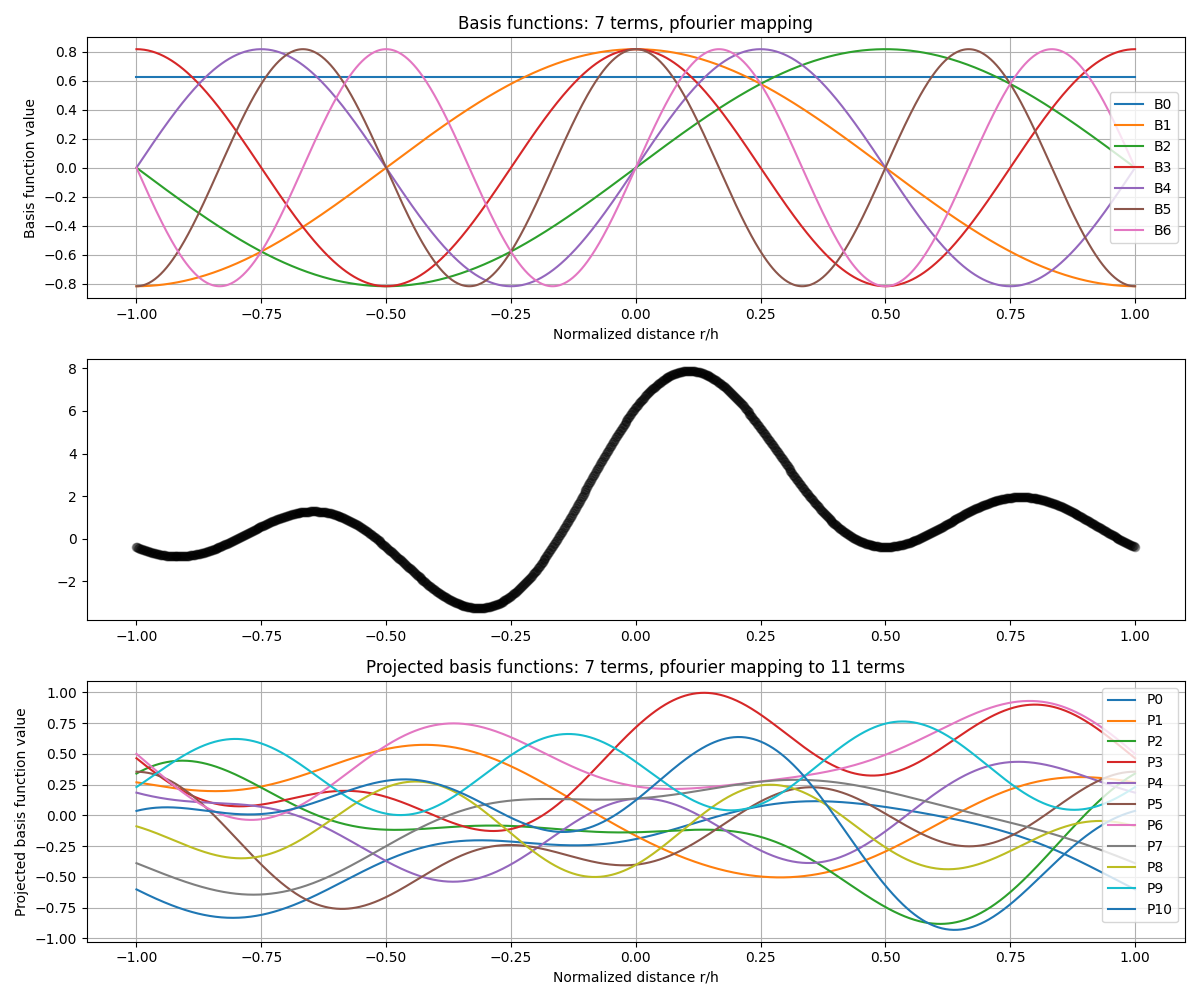

In [14]:

from layers.basisFunctions import basisEncoderLayer, evalBasisFunction

e = torch.linspace(-1,1, steps = 2**10, device=device, dtype=dtype)

# e = edge_attr[:,0]

dim = 2

b = 7
f = 'pfourier'
bTerm = evalBasisFunction(b, e, f).mT #* np.sqrt(2)

# for bi in range(b):
    # bTerm[:,bi] = bTerm[:,bi] if bi % 2 == 1 else - bTerm[:,bi]

fig, axis = plt.subplots(3, 1, figsize=(12,10), squeeze=False)

for i in range(bTerm.shape[-1]):
    axis[0,0].plot(e.cpu(), bTerm[:,i].cpu(), label=f'B{i}')
    # axis[0,0].scatter(e.cpu(), bTerm[:,i].cpu(), alpha=0.3)
# axis[0,0].scatter(e.cpu(), bTerm.cpu())
axis[0,0].legend()
axis[0,0].set_title(f'Basis functions: {b} terms, {f} mapping')
axis[0,0].set_xlabel('Normalized distance r/h')
axis[0,0].set_ylabel('Basis function value')
axis[0,0].grid()

printTensor('e', e.view(-1,1))
printTensor('bTerm', bTerm)

# print(bTerm[:,])

# # concat version
bTerm = torch.cat([bTerm]*dim, dim=-1)
# # outer product version
# if dim == 1:
#     pass
# elif dim == 2:
#     bTerm = torch.einsum('bi,bj->bij', bTerm, bTerm).view(bTerm.shape[0], -1)
# elif dim == 3:
#     bTerm = torch.einsum('bi,bj,bk->bijk', bTerm, bTerm, bTerm).view(bTerm.shape[0], -1)
# else:
#     raise ValueError(f'Unsupported dimension: {dim}')


axis[1,0].scatter(e.cpu(), bTerm.sum(dim=1).cpu(), label='1', color='black', alpha=0.3)


linPro = nn.Linear(bTerm.shape[-1], 11).to(device)
proj = linPro(bTerm).detach()
printTensor('Projected basis terms', proj)



for i in range(proj.shape[-1]):
    axis[2,0].plot(e.cpu(), proj[:,i].cpu(), label=f'P{i}')
    # axis[2,0].scatter(e.cpu(), proj[:,i].cpu(), alpha=0.3)
# axis[2,0].scatter(e.cpu(), proj.cpu())
axis[2,0].legend()
axis[2,0].set_title(f'Projected basis functions: {b} terms, {f} mapping to {proj.shape[-1]} terms')
axis[2,0].set_xlabel('Normalized distance r/h')
axis[2,0].set_ylabel('Projected basis function value')
axis[2,0].grid()

fig.tight_layout()

In [15]:
ratios = []
in_features = bTerm.shape[-1]
out_features = 17

for i in range(2**8):
    linPro = nn.Linear(bTerm.shape[-1], 11, bias = False).to(device)

    nn.init.uniform_(linPro.weight, a=-1/np.sqrt(in_features) * np.sqrt(3), b=1/np.sqrt(in_features) * np.sqrt(3))

    proj = linPro(bTerm).detach()
    ratios.append(proj.std().item())
print('Std ratios of random projections:', ratios)

meanStd = np.mean(ratios)
print('Mean std of random projections:', meanStd)

ratio = bTerm.std().item() / meanStd
print('Scaling ratio:', ratio)

Std ratios of random projections: [0.5424374938011169, 0.5461258292198181, 0.6290815472602844, 0.6205569505691528, 0.5380029082298279, 0.579419732093811, 0.5963990092277527, 0.5847994089126587, 0.6116092205047607, 0.5482573509216309, 0.6256361603736877, 0.5193408727645874, 0.6134454011917114, 0.611103355884552, 0.6643614172935486, 0.5791142582893372, 0.5880555510520935, 0.538754940032959, 0.6288378238677979, 0.555915355682373, 0.6189708113670349, 0.6232717037200928, 0.5650944709777832, 0.6498777866363525, 0.6199929118156433, 0.5560824871063232, 0.5605083107948303, 0.5789897441864014, 0.590337336063385, 0.5147067308425903, 0.5774763226509094, 0.5639990568161011, 0.5524535775184631, 0.5851760506629944, 0.559546709060669, 0.5320829749107361, 0.6448687314987183, 0.6188125014305115, 0.6213718056678772, 0.5441612601280212, 0.5804124474525452, 0.5590624213218689, 0.5738657712936401, 0.5487623810768127, 0.6140287518501282, 0.6229453086853027, 0.5459085702896118, 0.5593248009681702, 0.567347526

In [31]:
from layers.mlp import buildMLPwDict, getDefaultMLPDict

ratios = []
mlpDict = getDefaultMLPDict()
mlpDict['activation'] = 'none'
mlpDict['layout'] = [64,64]


for i in range(2**8):
    mlp = buildMLPwDict(mlpDict, inputDim = in_features, outputDim = out_features)

    proj = mlp(bTerm).detach()
    ratios.append(proj.std().item())
print('Std ratios of random projections:', ratios)

meanStd = np.mean(ratios)
print('Mean std of random projections:', meanStd)

ratio = bTerm.std().item() / meanStd
print('Scaling ratio:', ratio)

Std ratios of random projections: [0.5453553199768066, 0.5016560554504395, 0.5207997560501099, 0.5414156317710876, 0.49225521087646484, 0.5650356411933899, 0.45603111386299133, 0.4824237823486328, 0.48215004801750183, 0.5762501358985901, 0.54059898853302, 0.496574342250824, 0.5671325922012329, 0.4770881235599518, 0.5068327784538269, 0.5215007066726685, 0.5392895936965942, 0.5229483842849731, 0.4471007287502289, 0.5291978120803833, 0.5488344430923462, 0.45028242468833923, 0.5151927471160889, 0.5024734139442444, 0.4602218568325043, 0.5749745965003967, 0.5150103569030762, 0.5503712892532349, 0.548578679561615, 0.48867127299308777, 0.5497832894325256, 0.6282420754432678, 0.550923228263855, 0.5106989741325378, 0.47064629197120667, 0.4828208386898041, 0.4291841387748718, 0.5250584483146667, 0.44720351696014404, 0.4880252480506897, 0.5143498778343201, 0.5349870920181274, 0.5305304527282715, 0.4528046250343323, 0.4993797838687897, 0.548193633556366, 0.4552498757839203, 0.47727057337760925, 0.5

In [31]:
np.sqrt(3)

np.float64(1.7320508075688772)

0.5773506164550781


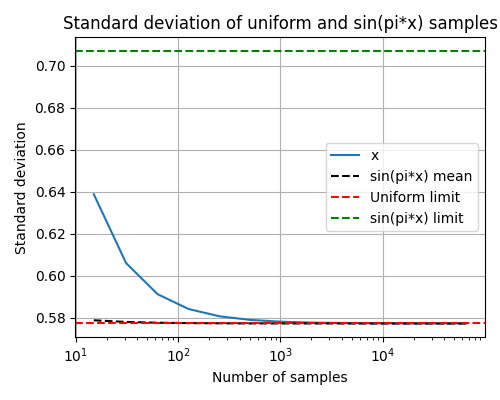

In [16]:

b = 15
f = 'pfourier'
nx = [2**i - 1 for i in range(4,17)]

xstd = []
fxstd  = []
fstd = []

for n in nx:
    xx = torch.linspace(-1,1, steps = n, device=device, dtype=dtype)
    xstd.append(xx.std().item() )

    basisTerms = evalBasisFunction(b, xx, 'pfourier').mT #* np.sqrt(2)
    # print(basisTerms.shape)
    # scaling = np.sqrt(2) / 6 *np.sqrt(12)
    # basisTerms[:,0] = 1/np.sqrt(2) / np.sqrt((b-1)/b) * scaling  # constant term should not be scaled
    # basisTerms[:,1:] = basisTerms[:,1:] / scaling #* np.sqrt(2) # scale other terms to have std = 1/sqrt(2)

    # basisTerms = basisTerms[:,1:]

    # fx = torch.sin(xx*np.pi) #* np.sqrt(2)
    fxstd.append((basisTerms.std(dim=0).cpu().numpy()))
    fstd.append(basisTerms.std().item())
    
fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
axis[0,0].plot(nx, xstd, label='x')
# print(fxstd)
print(fstd[-1])
fxstd = np.vstack(fxstd)

# axis[0,0].plot(nx, fxstd)
axis[0,0].plot(nx, fstd, label='sin(pi*x) mean', color='black', linestyle='--')
# axis[0,0].set_yscale('log')
axis[0,0].set_xscale('log')
axis[0,0].legend()
axis[0,0].set_title('Standard deviation of uniform and sin(pi*x) samples')
axis[0,0].set_xlabel('Number of samples')
axis[0,0].set_ylabel('Standard deviation')
axis[0,0].grid()

axis[0,0].axhline(y=2/np.sqrt(12), color='r', linestyle='--', label='Uniform limit')
axis[0,0].axhline(y=1/np.sqrt(2), color='g', linestyle='--', label='sin(pi*x) limit')
axis[0,0].legend()

fig.tight_layout()

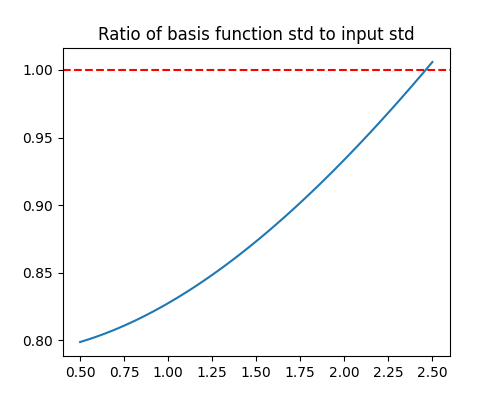

In [93]:
xx = torch.linspace(0.5,2.5, steps = 127, device=device, dtype=dtype)

basisTerms = evalBasisFunction(b, xx, 'pfourier').mT #* np.sqrt(2)

ratios = []
for x in xx:
    basisTerms[:,0] = x / np.sqrt(2)
    ratio = basisTerms.std() * np.sqrt(2)
    ratios.append(ratio.item())

fig, axis = plt.subplots(1,1 , figsize=(5,4), squeeze=False)
axis[0,0].plot(xx.cpu(), ratios)
axis[0,0].set_title('Ratio of basis function std to input std')
axis[0,0].axhline(y=1, color='r', linestyle='--', label='Ideal ratio')


np.float64(0.5773502691896258)

In [67]:
fstd

[0.718532383441925,
 0.7160053849220276,
 0.7147958278656006,
 0.7142038345336914,
 0.7139109373092651,
 0.7137652635574341,
 0.7136926651000977,
 0.7136563658714294,
 0.7136382460594177,
 0.7136291861534119,
 0.7136246562004089,
 0.7136223912239075,
 0.7136212587356567]

In [65]:
((b-1)/b)**2

0.8711111111111112

In [63]:
1/np.sqrt(2) / fstd[-1]

np.float64(1.0011457839571245)

In [ ]:
np.sqrt(6)

np.float64(2.449489742783178)

--------------------------------------------------------------------------------
Tensor Projected basis terms: shape torch.Size([127, 11]), dtype torch.float32, device cpu
	min: -0.7688883543014526, max: 0.6874650716781616, mean: -0.015834245830774307, std: 0.2866215109825134
	Channel 0: min: -0.2893196940422058, max: 0.5624982714653015, mean: 0.13587680459022522, std: 0.272249311208725, data: 
	Channel 1: min: -0.7688883543014526, max: 0.23320144414901733, mean: -0.242934450507164, std: 0.27466168999671936, data: 
	Channel 2: min: -0.38937854766845703, max: 0.154067724943161, mean: -0.13628366589546204, std: 0.1602659374475479, data: 
	Channel 3: min: -0.3371296525001526, max: 0.6874650716781616, mean: 0.16865840554237366, std: 0.26427221298217773, data: 
	Channel 4: min: -0.13563945889472961, max: 0.6188693642616272, mean: 0.21308478713035583, std: 0.20323523879051208, data: 
	Channel 5: min: -0.4993593394756317, max: 0.023286789655685425, mean: -0.25306057929992676, std: 0.159824475

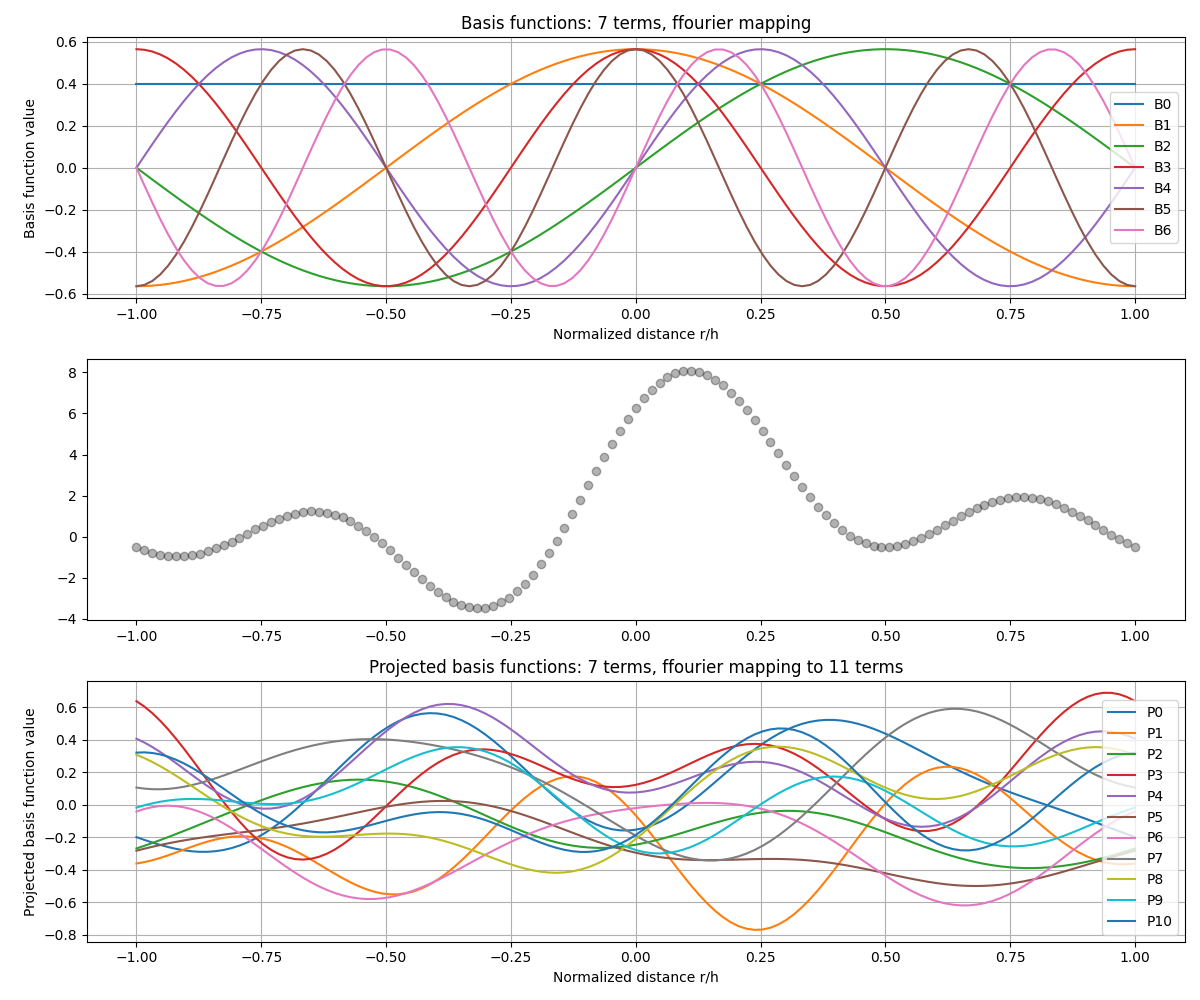

In [66]:

from layers.basisFunctions import basisEncoderLayer, evalBasisFunction

e = torch.linspace(-1,1, steps = 127, device=device, dtype=dtype)

# e = edge_attr[:,0]

dim = 3

b = 7
f = 'ffourier'
bTerm = evalBasisFunction(b, e, f).mT

fig, axis = plt.subplots(3, 1, figsize=(12,10), squeeze=False)

for i in range(bTerm.shape[-1]):
    axis[0,0].plot(e.cpu(), bTerm[:,i].cpu(), label=f'B{i}')
    # axis[0,0].scatter(e.cpu(), bTerm[:,i].cpu(), alpha=0.3)
# axis[0,0].scatter(e.cpu(), bTerm.cpu())
axis[0,0].legend()
axis[0,0].set_title(f'Basis functions: {b} terms, {f} mapping')
axis[0,0].set_xlabel('Normalized distance r/h')
axis[0,0].set_ylabel('Basis function value')
axis[0,0].grid()

# printTensor('bTerm', bTerm)

# print(bTerm[:,])

# concat version
bTerm = torch.cat([bTerm]*dim, dim=-1)
# outer product version
# if dim == 1:
#     pass
# elif dim == 2:
#     bTerm = torch.einsum('bi,bj->bij', bTerm, bTerm).view(bTerm.shape[0], -1)
# elif dim == 3:
#     bTerm = torch.einsum('bi,bj,bk->bijk', bTerm, bTerm, bTerm).view(bTerm.shape[0], -1)
# else:
#     raise ValueError(f'Unsupported dimension: {dim}')


axis[1,0].scatter(e.cpu(), bTerm.sum(dim=1).cpu(), label='1', color='black', alpha=0.3)


linPro = nn.Linear(bTerm.shape[-1], 11).to(device)
proj = linPro(bTerm).detach()
printTensor('Projected basis terms', proj)



for i in range(proj.shape[-1]):
    axis[2,0].plot(e.cpu(), proj[:,i].cpu(), label=f'P{i}')
    # axis[2,0].scatter(e.cpu(), proj[:,i].cpu(), alpha=0.3)
# axis[2,0].scatter(e.cpu(), proj.cpu())
axis[2,0].legend()
axis[2,0].set_title(f'Projected basis functions: {b} terms, {f} mapping to {proj.shape[-1]} terms')
axis[2,0].set_xlabel('Normalized distance r/h')
axis[2,0].set_ylabel('Projected basis function value')
axis[2,0].grid()

fig.tight_layout()

In [20]:
testLinear = nn.Linear(inputFeatures.shape[-1], 11).to(device)

test = testLinear(inputFeatures.unsqueeze(0))


printTensor('test', test)

--------------------------------------------------------------------------------
Tensor test: shape torch.Size([1, 256, 11]), dtype torch.float32, device cpu
	min: -1.956415057182312, max: 1.761480450630188, mean: 0.24556903541088104, std: 0.7779693007469177
	Channel 0: min: -0.4281860589981079, max: 1.449626088142395, mean: 0.5107200145721436, std: 0.6652073264122009, data: 
	Channel 1: min: 0.16183137893676758, max: 0.3152298927307129, mean: 0.23853063583374023, std: 0.054340802133083344, data: 
	Channel 2: min: -1.956415057182312, max: 0.029319405555725098, mean: -0.963547945022583, std: 0.703438401222229, data: 
	Channel 3: min: -0.9228988885879517, max: -0.7488380670547485, mean: -0.8358684778213501, std: 0.06166033819317818, data: 
	Channel 4: min: -0.07050156593322754, max: 0.8916032314300537, mean: 0.4105508327484131, std: 0.3408217132091522, data: 
	Channel 5: min: 0.6467076539993286, max: 1.119041085243225, mean: 0.8828743696212769, std: 0.16732221841812134, data: 
	Channel 6

In [ ]:
basicModel.inputEncoder.

BasicEncoder(
  (encoder): TokenEncoder(
    (input_encoder): Sequential(
      (linear0): Linear(in_features=1, out_features=64, bias=True)
      (activation0): Sigmoid()
      (linear1): Linear(in_features=64, out_features=64, bias=True)
      (activation1): Sigmoid()
      (linear2): Linear(in_features=64, out_features=11, bias=False)
    )
    (final_activation): Identity()
  )
)

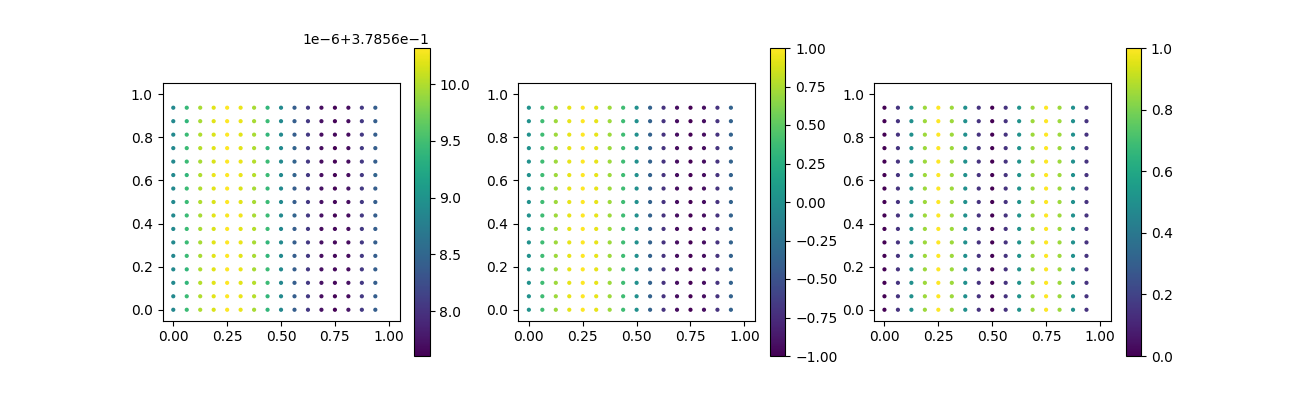

In [16]:
fig, axis = plt.subplots(1, 3, figsize=(13, 4), squeeze = False)

plot = visualizeParticles(fig, axis[0, 0],
  particles = particleState,
  domain = domain,
  quantity = basicPred.detach(),
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 2],
  particles = particleState,
  domain = domain,
  quantity = gt,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
    visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)

plot = visualizeParticles(fig, axis[0, 1],
  particles = particleState,
  domain = domain,
  quantity = inputFeatures,
  which = 'fluid',
  mapping = '.x',
  cmap = 'viridis',
  visualizeBoth=False,
  kernel = kernel,
  plotDomain = False,
  gridVisualization=False, markerSize=4,
  streamLines = False)


In [17]:
optimizer = torch.optim.Adam(basicModel.parameters(), lr=1e-2)
numberOfParameters = count_parameters(basicModel)
print(f'Number of parameters in the model: {numberOfParameters}')

basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0)

print(basicPred)

Number of parameters in the model: 11667
--------------------------------------------------------------------------------
Tensor node_attr: shape torch.Size([1, 256, 1]), dtype torch.float32, device cpu
	min: -1.0, max: 1.0, mean: 5.587935447692871e-09, std: 0.7084919214248657
tensor([[[ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
         [ 3.8268e-01],
  

In [16]:
losses_transformer2 = []
for i in (tq := tqdm(range(2**14), desc='Training', unit='epoch')) :
    optimizer.zero_grad()
    basicPred = basicModel(node_attr[0], edge_attr, edge_indices, node_positions[0]).squeeze(0) * 100

    # print(basicPred.shape, gt.shape)
    # print(basicPred)
    fluidPred = basicPred#[particleState.kinds == 0]
    fluidGT = gt#[particleState.kinds == 0]

    fluidLoss = torch.nn.functional.mse_loss(fluidPred, fluidGT)

    fluidLoss = ((fluidPred - fluidGT)**2).mean()
    # print('Fluid loss:', fluidLoss.item())

    # loss = torch.nn.functional.mse_loss(basicPred, gt)
    fluidLoss.backward()
    optimizer.step()
    tq.set_postfix({'loss': fluidLoss.item()})
    losses_transformer2.append(fluidLoss.item())

    # break

Training:   0%|          | 0/16384 [00:00<?, ?epoch/s]

Input node_attr shape: torch.Size([1, 256, 1])
Encoded input shape: torch.Size([1, 256, 11])
#                          BasisEncoder Forward Pass                           #
EdgeEnc|	Input Positions shape: torch.Size([11520, 2]), min: -0.75, max: 0.75, mean: 0.0, std: 0.4714147448539734
EdgeEnc|	Input Positions dim 0: min: -0.75, max: 0.75, mean: 0.0, std: 0.47142499685287476
EdgeEnc|	Input Positions dim 1: min: -0.75, max: 0.75, mean: 0.0, std: 0.47142499685287476
EdgeEnc|	Input Positions lengths: min: 0.0, max: 0.9013878107070923, mean: 0.6277874708175659, std: 0.22434738278388977
EdgeEnc|Input positions shape before shapeMatch: torch.Size([11520, 2])
EdgeEnc|Input positions shape after shapeMatch: torch.Size([11520, 2]), batches=1, entries=11520, dim=2
EdgeEnc|	Applying basis encoding with functions ['ffourier', 'ffourier'] and terms [6, 6]
EdgeEnc|	Combined basis terms shape: torch.Size([11520, 12])
EdgeEnc|	Activated basis terms shape: torch.Size([11520, 12])
EdgeEnc|	Applying pro

KeyboardInterrupt: 

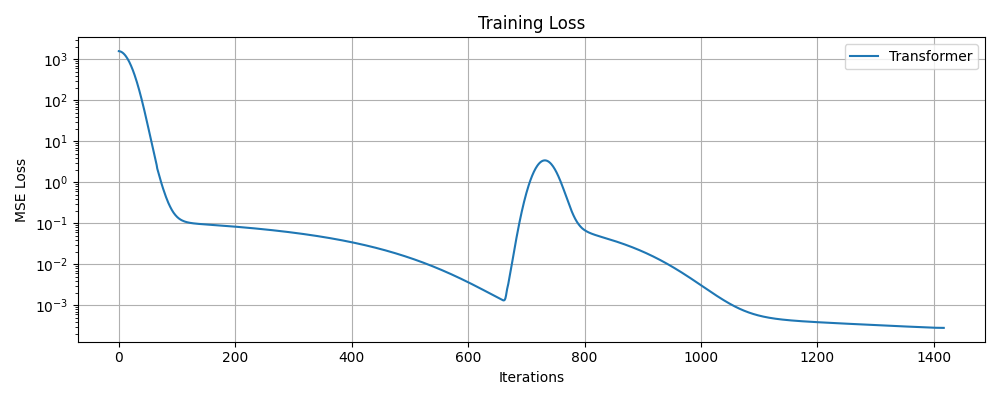

In [143]:
fig, axis = plt.subplots(1,1 , figsize=(10,4), squeeze=False)

# axis[0,0].plot(gaussian_filter1d(losses, sigma=16), label = 'GNN')
# axis[0,0].plot(gaussian_filter1d(losses_transformer, sigma=16), label = 'Transformer')
axis[0,0].plot(gaussian_filter1d(losses_transformer2, sigma=16), label = 'Transformer')
# axis[0,0].plot(gaussian_filter1d(losses_cconv, sigma=16), label = 'CConv')

axis[0,0].set_yscale('log')
axis[0,0].set_title('Training Loss')
axis[0,0].legend()

axis[0,0].grid(True)
axis[0,0].set_xlabel('Iterations')
axis[0,0].set_ylabel('MSE Loss')

fig.tight_layout()

In [ ]:

pred = basicPred.squeeze(0)

print('pred shape:', pred.shape, 'gt shape:', gt.shape)

loss = torch.nn.functional.mse_loss(pred, gt)
print('Loss:', loss.item())

pred shape: torch.Size([17196, 2]) gt shape: torch.Size([17196, 2])
Loss: 0.06757645308971405


In [ ]:
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel


cconvModel = CConvModel(
    config=baseConfig,

    verbose = False,
).to(device)

cconvModelNoEncoders = CConvModel(
    config=baseConfigNoEncoders,

    verbose = False,
).to(device)


In [ ]:
outA = cconvModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(cconvModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [ ]:
from models.GNN import GNNModel

gnn = GNNModel(
    config = baseConfig,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

gnnNoEncoders = GNNModel(
    config = baseConfigNoEncoders,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

In [ ]:
outA = gnn(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(gnnNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))